<div style="text-align: center;">

<!-- color:#e06666 -->
<h3 style="font-weight: normal; margin-bottom: 10px;">
EN3160 Assignment 01
</h3>

<h3 style="font-weight: normal; line-height: 1.5; margin-top: 0;">
Intensity Transformations and Neighborhood Filtering
</h3>

<!-- <br><br> -->

<h4 style="font-family: 'Times New Roman', serif; font-weight: normal; margin-top: 0; line-height: 1.4;">
230138K  - K.T.G.T.N.Dhananjaya 
</h4>


</div>

<a href="https://github.com/TharushaNimesh22/intensity-transformations-and-neighborhood-filtering">GitHub Link: https://github.com/TharushaNimesh22/intensity-transformations-and-neighborhood-filtering </a>

##### 1. Intensity transformation

Intensity transformation function was implemented using user defined breakpoints. For each pair of breakpoints, the slope and intercept of the corresponding linear segment are calculated and applied to the image intensities. The implementation also handles discontinuities.

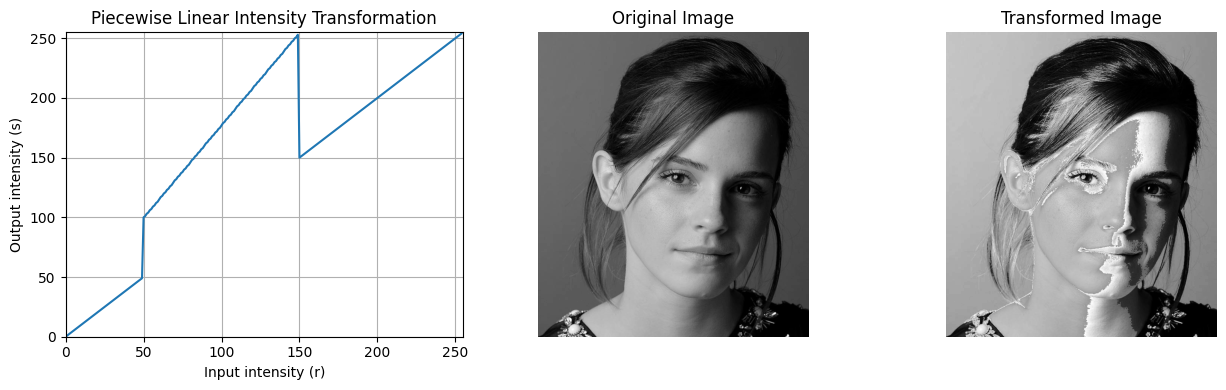

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    transformed = np.zeros_like(im, dtype=np.uint8)
    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        # Calculate the slope (m) and intercept (b) of the line segment
        if x1 - x0 != 0:
            m = (y1 - y0) / (x1 - x0)
            b = y0 - m * x0
        else:
            m, b = 0, y0
        # Apply the linear transformation for the current segment
        mask = (im >= x0) & (im < x1)
        transformed[mask] = np.clip(m * im[mask] + b, 0, 255)
    return transformed.astype(np.uint8)

im = cv.imread("images/emma.jpeg", cv.IMREAD_GRAYSCALE)
breakpoints = np.array([[0, 0], [50, 50],[50, 100], [150, 255],[150, 150], 
                        [255, 255],])
transformed = intensity_transform(im, breakpoints)

# Plot the transformation function
r = np.arange(255)
s = intensity_transform(r, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# Transformation function
axes[0].plot(r, s)    
axes[0].set(xlabel="Input intensity (r)", ylabel="Output intensity (s)", 
            title="Piecewise Linear Intensity Transformation", 
            xlim=(0, 255), ylim=(0, 255))
axes[0].grid()

# Original image
axes[1].imshow(im, cmap="gray")    
axes[1].set_title("Original Image")
axes[1].axis("off")

# Transformed image
axes[2].imshow(transformed, cmap="gray")  
axes[2].set_title("Transformed Image")
axes[2].axis("off")
plt.tight_layout()
plt.show()

According to the given breakpoints, only the intensity values between 50 and 150 undergo the specified transformation. As seen in the output image, the middle range values have become lighter.

##### 2. Intensity transformers for white matter and gray matter

##### a. White matter enhancement

Created a lookup table that converts pixel intensities below 180 to black and intensities from 180 to 255 to white.

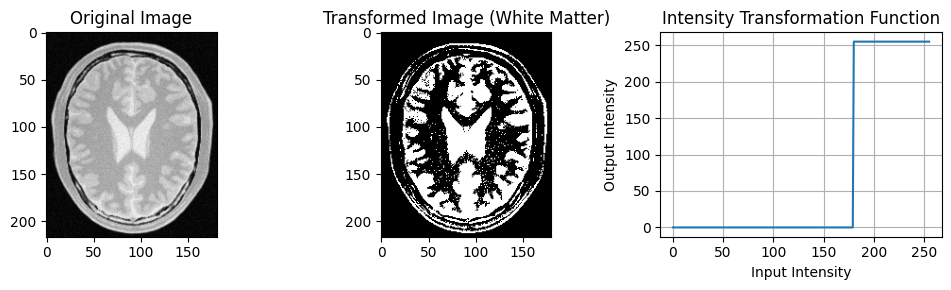

In [ ]:
f = cv.imread("images/brain.png", cv. IMREAD_GRAYSCALE)

region1 = np.linspace(0, 0, 180, endpoint=False).astype("uint8")
region2 = np.linspace(255, 255, 76).astype("uint8")
transform = np.concatenate((region1, region2)).reshape(256, 1)
white_matter = cv.LUT(f, transform)

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")

ax[1].imshow(white_matter, cmap='gray', vmin=0, vmax=255)
ax[1].set_title("Transformed Image (White Matter)")

ax[2].plot(transform)
ax[2].set_title("Intensity Transformation Function")
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)

plt.tight_layout()
plt.show()

The transformed image highlights the white matter regions by converting pixels above the selected threshold into white while reducing the lower intensity values to black.

##### b. Gray matter enhancement

Created a lookup table that converts pixel intensities from (0, 119) to black, (120, 199) to white, and (200, 255) back to black.

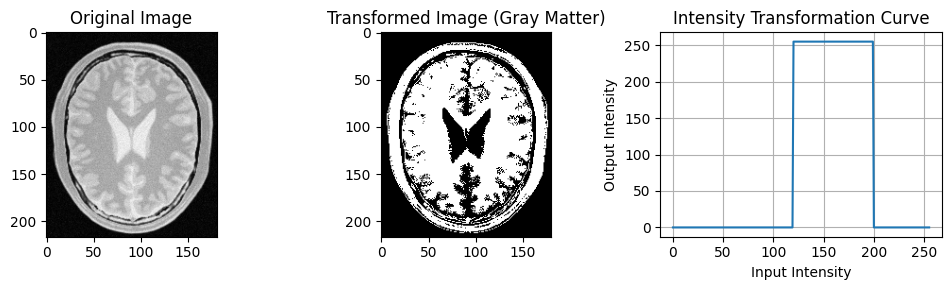

In [8]:
region1 = np.linspace(0, 0, 120, endpoint=False).astype("uint8")
region2 = np.linspace(255, 255, 80, endpoint=False).astype("uint8")
region3 = np.linspace(0, 0, 56).astype("uint8")
transform = np.concatenate((region1, region2, region3)).reshape(256, 1)
gray_matter = cv.LUT(f, transform)

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")

ax[1].imshow(gray_matter, cmap='gray', vmin=0, vmax=255)
ax[1].set_title("Transformed Image (Gray Matter)")
ax[2].plot(transform)

ax[2].set_title("Intensity Transformation Curve") 
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)

plt.tight_layout()
plt.show()

The transformed image highlights the intensity range associated with the target region as white. Other intensity ranges are suppressed to black.

##### 3. Gamma correction

The image was converted to the L\*a\*b* color space, and the L plane was separated. Gamma correction with \($\gamma$ = 0.5\) was applied to the L plane. The corrected L plane was then combined with the original a* and b* planes to produce the corrected image.

Gamma Value: 0.5


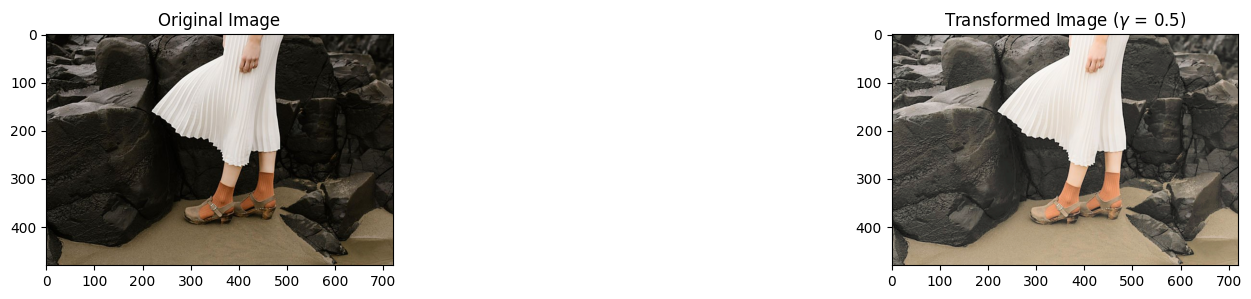

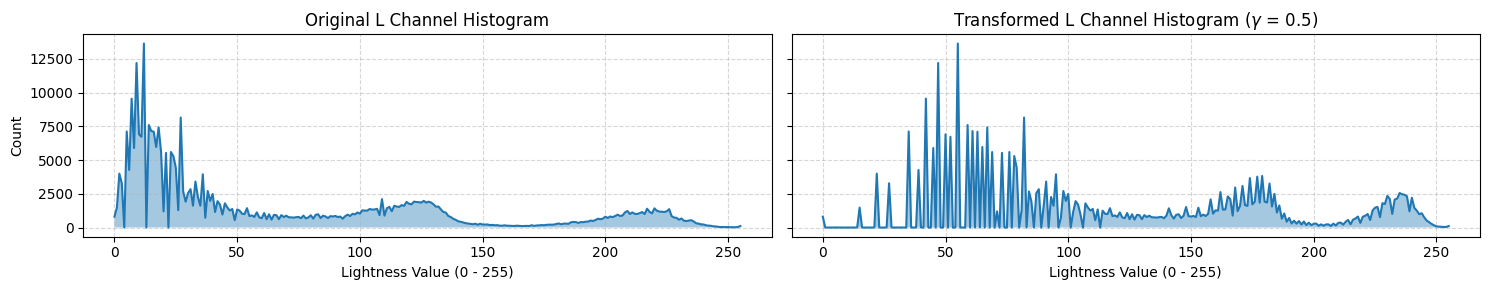

In [ ]:
gamma = 0.5
print(f"Gamma Value: {gamma}")

img = cv.imread("images/girl.jpeg")
rgb_original = cv.cvtColor(img, cv.COLOR_BGR2RGB)

lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab) #splitting to L*a*b planes

# Gamma correction transformation
transform = np.array([(((i/255) ** gamma)*255) for i in range(256)],
                      dtype=np.uint8)
L_new = cv.LUT(L, transform) 

corrected_img = cv.merge([L_new, a, b])
bgr_output = cv.cvtColor(corrected_img, cv.COLOR_LAB2BGR)
rgb_output = cv.cvtColor(bgr_output, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(20, 3))

ax[0].imshow(rgb_original)
ax[0].set_title("Original Image")

ax[1].imshow(rgb_output)
ax[1].set_title(rf"Transformed Image ($\gamma$ = {gamma})")

# Plotting the histogram
hist_before = cv.calcHist([L], [0], None, [256], [0, 256])
hist_after = cv.calcHist([L_new], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(15, 3), sharey=True)
# Original L Channel Histogram
ax[0].plot(hist_before, linewidth=1.5)
ax[0].fill_between(range(256), hist_before.ravel(), alpha=0.4)
ax[0].set_title("Original L Channel Histogram")
ax[0].set_xlabel("Lightness Value (0 - 255)")
ax[0].set_ylabel("Count")
ax[0].grid(True, linestyle="--", alpha=0.5)

# Transformed L Channel Histogram
ax[1].plot(hist_after, linewidth=1.5)
ax[1].fill_between(range(256), hist_after.ravel(), alpha=0.4)
ax[1].set_title(rf"Transformed L Channel Histogram ($\gamma$ = {gamma})")
ax[1].set_xlabel("Lightness Value (0 - 255)")
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

The gamma corrected image appeared brighter than the original image, particularly in the darker regions. This indicates that gamma correction with $\gamma$ < 1 increases the brightness of the image.

##### 4. Enhance the vibrance of an image

The image was converted to the HSV color space and the saturation plane was separated. The given intensity transformation was applied to the saturation plane using 0 < a < 1 and $\sigma$=70. The corrected saturation plane was then combined with the original hue and value planes to obtain the enhanced image.


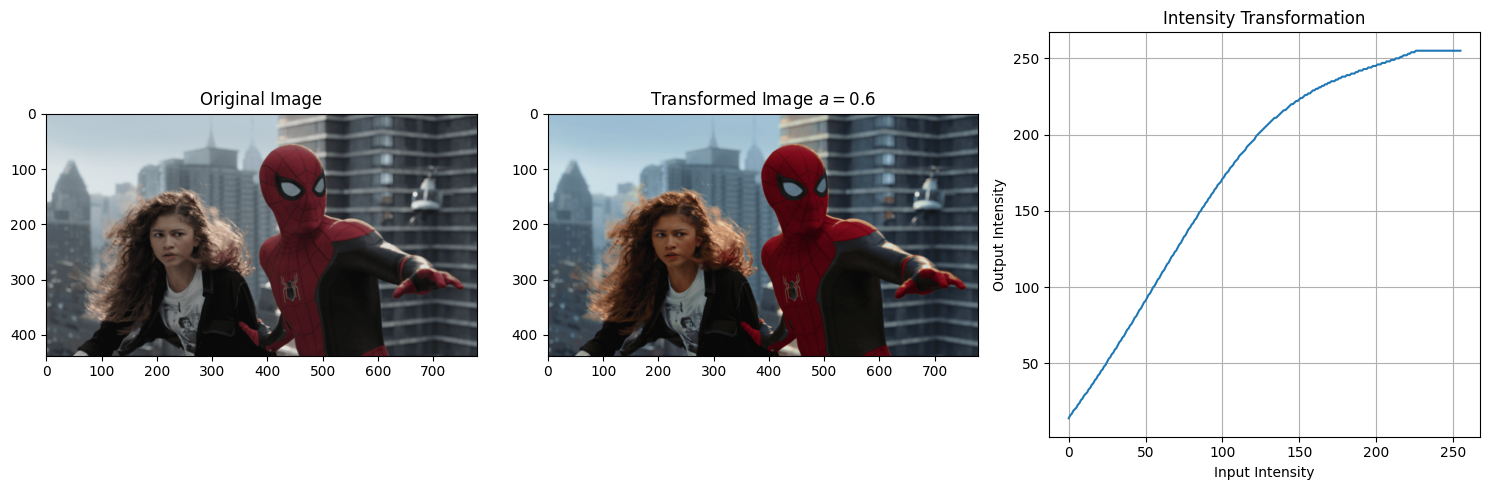

In [ ]:
a = 0.6
sigma = 70

img = cv.imread("images/peter.png")
rgb_original = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

# Transformation function for saturation channel
def f(x):
    value = x + a * 128 * np.exp(-(x - 128) ** 2 / (2 * sigma ** 2))    
    return min(value,255)

transform = np.array([np.round(f(i)) for i in range(256)], dtype=np.uint8)
s_new = cv. LUT(s, transform) # Applying the transformation
modified_img = cv.merge([h, s_new,v])

bgr_output  = cv.cvtColor(modified_img, cv.COLOR_HSV2BGR)
rgb_output = cv.cvtColor(bgr_output, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgb_original)
ax[0].set_title("Original Image")

ax[1].imshow(rgb_output)
ax[1].set_title(f"Transformed Image $a=${a}")

ax[2].plot(transform)
ax[2].set_title("Intensity Transformation")
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)

plt.tight_layout()
plt.show()

When a=0, no change was observed in the output image. At a=1, the colors appeared unnatural due to excessive saturation. When a was gradually increased from 0, a visually pleasing output was observed at a=0.6.

##### 5. Histogram equalizer

The histogram and CDF of the grayscale image were calculated, and then that CDF was used to create a transformation function. The transformation was then applied to the image to obtain the histogram equalized image.


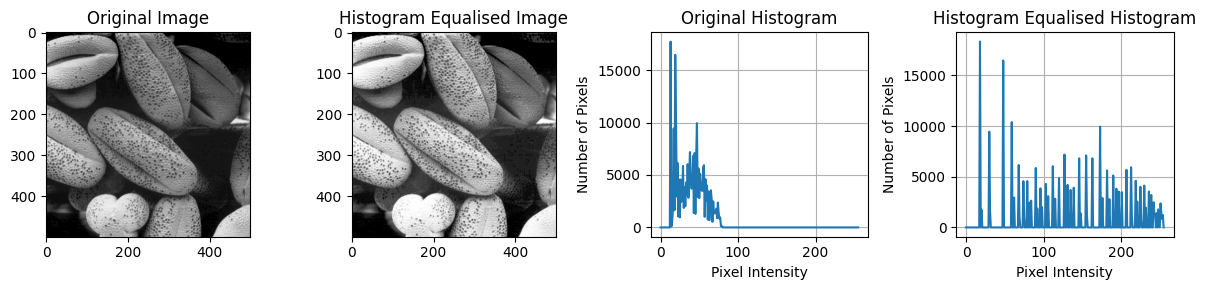

In [ ]:
img = cv.imread("images/shells.tif", cv.IMREAD_GRAYSCALE)

# Histogram Equalization
def hist_equalization(img):
    hist = cv.calcHist([img], [0], None, [256], [0, 256])
    cdf = hist.cumsum()
    M, N = img.shape
    transform = np.array([(255 * cdf[i]) / (M * N) for i in range(256)]).astype(np.uint8)
    return transform

transform = hist_equalization(img)
output_img = cv.LUT(img, transform)
hist_original = cv.calcHist([img], [0], None, [256], [0, 256])
hist_new = cv.calcHist([output_img], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original Image")

ax[1].imshow(output_img, cmap='gray')
ax[1].set_title("Histogram Equalised Image")

ax[2].plot(hist_original)
ax[2].set_title("Original Histogram")
ax[2].set_xlabel("Pixel Intensity")
ax[2].set_ylabel("Number of Pixels")
ax[2].grid(True)

ax[3].plot(hist_new)
ax[3].set_title("Histogram Equalised Histogram")
ax[3].set_xlabel("Pixel Intensity")
ax[3].set_ylabel("Number of Pixels")
ax[3].grid(True)

plt.tight_layout()
plt.show()

The histogram equalized image showed improved contrast compared with the original image. The intensity values of the equalized histogram were distributed over a wider range indicating an improvement in the overall contrast.

##### 6. Histogram equalized foreground

The image was converted to the HSV color space, and the saturation plane was separated using a threshold to obtain the foreground mask. The foreground was then extracted, and histogram equalization was applied to its value plane using the CDF. Finally, the equalized foreground and the original background were combined together to obtain the final image.


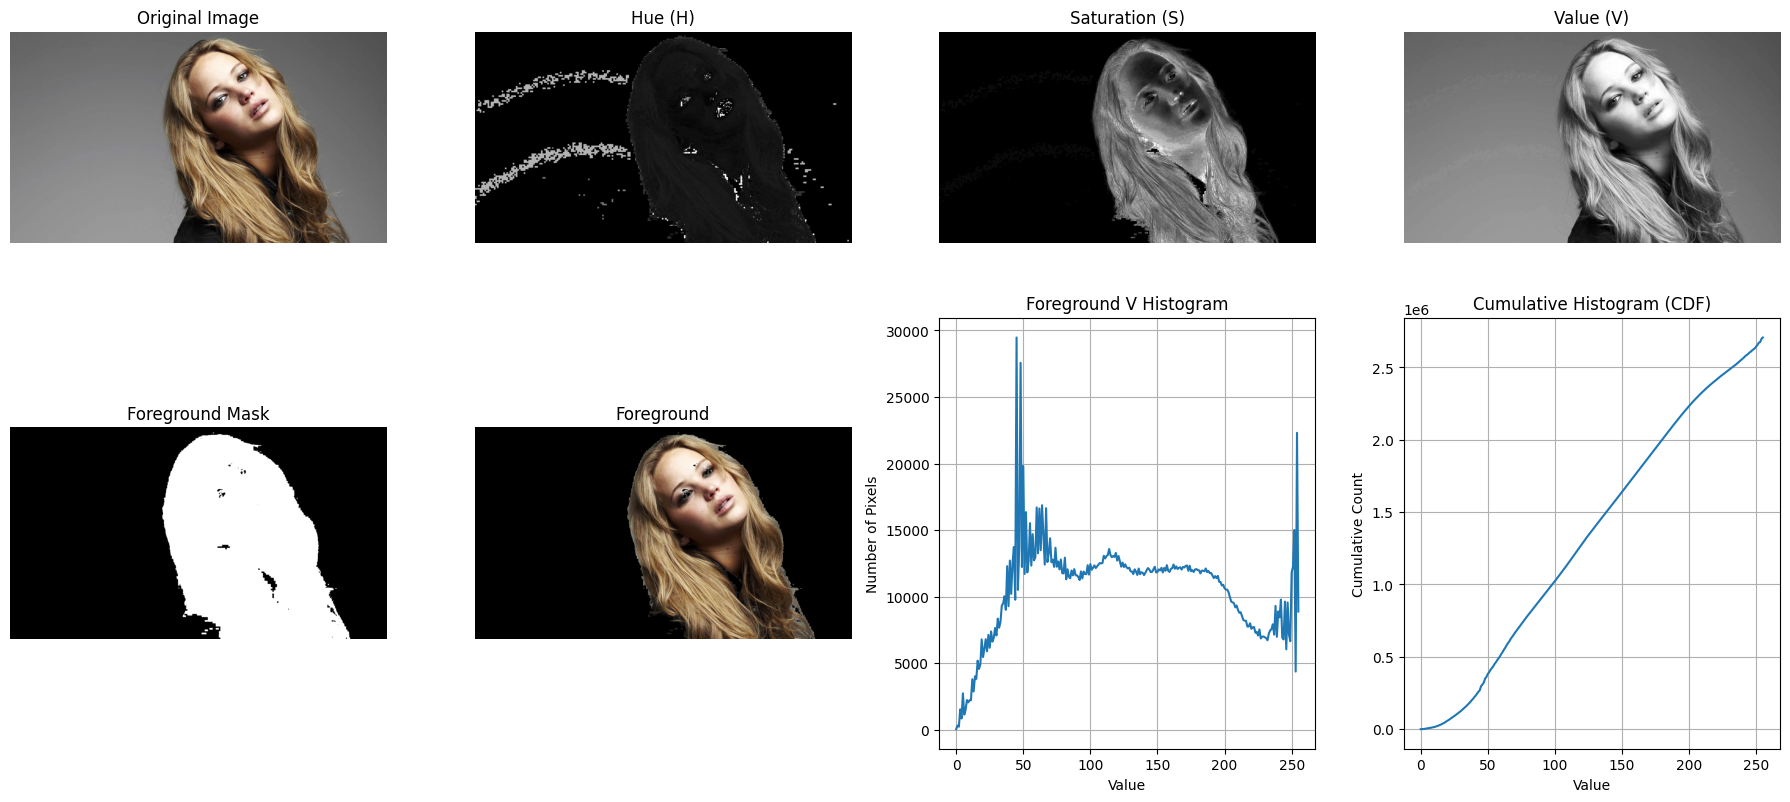

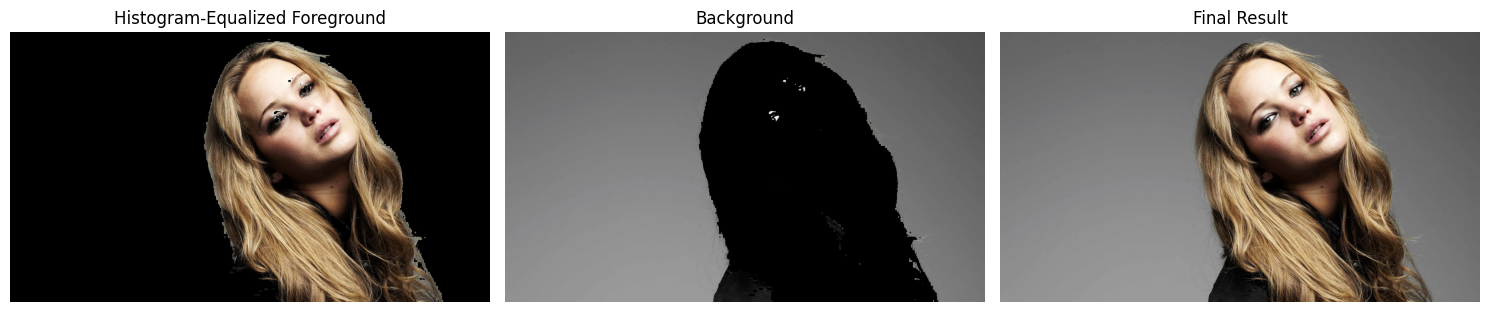

In [ ]:
# a. Open image, convert to HSV
img = cv.imread("images/jennifer.jpeg")
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

# b. Threshold the saturation plane to obtain foreground mask
_, mask = cv.threshold(s, 15, 255, cv.THRESH_BINARY)
# Remove small holes/noise in the mask
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
fg_mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)

# c. Extract foreground and compute its V-plane histogram
foreground = cv.bitwise_and(img, img, mask=fg_mask)
fg_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)
h1, s1, value_plane = cv.split(fg_hsv)

# Histogram of V values only inside the foreground
v_hist = cv.calcHist([value_plane], [0], fg_mask, [256], [0, 256]).flatten()

# d. Obtain cumulative sum of the histogram
cdf = np.cumsum(v_hist)
MN = np.count_nonzero(fg_mask) # Number of foreground pixels

# e. Histogram-equalize the foreground
# s = (L-1)/MN * sum(n_j)
L = 256

# Create the lookup table
eq_lut = np.round((L - 1) * cdf / MN).astype(np.uint8)

# Apply the transformation only to foreground pixels
value_equalized = value_plane.copy()
value_equalized[fg_mask > 0] = eq_lut[value_plane[fg_mask > 0]]

# Reconstruct HSV image
equalized_hsv = cv.merge([h1, s1, value_equalized])
equalized_img = cv.cvtColor(equalized_hsv, cv.COLOR_HSV2BGR)

# f. Extract background and combine it with equalized foreground
bg_mask = cv.bitwise_not(fg_mask)
background = cv.bitwise_and(img, img, mask=bg_mask)
equalized_fg = cv.bitwise_and(equalized_img, equalized_img, mask=fg_mask)
output_img = cv.add(equalized_fg, background)

fig, ax = plt.subplots(2, 4, figsize=(18, 9))
# Original image
ax[0, 0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[0, 0].set_title("Original Image")

# H, S, V planes
ax[0, 1].imshow(h, cmap="gray")
ax[0, 1].set_title("Hue (H)")

ax[0, 2].imshow(s, cmap="gray")
ax[0, 2].set_title("Saturation (S)")

ax[0, 3].imshow(v, cmap="gray")
ax[0, 3].set_title("Value (V)")

# Foreground mask
ax[1, 0].imshow(fg_mask, cmap="gray")
ax[1, 0].set_title("Foreground Mask")

# Foreground only
ax[1, 1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
ax[1, 1].set_title("Foreground")

# Histogram
ax[1, 2].plot(v_hist)
ax[1, 2].set_title("Foreground V Histogram")
ax[1, 2].set_xlabel("Value")
ax[1, 2].set_ylabel("Number of Pixels")
ax[1, 2].grid(True)

# CDF
ax[1, 3].plot(cdf)
ax[1, 3].set_title("Cumulative Histogram (CDF)")
ax[1, 3].set_xlabel("Value")
ax[1, 3].set_ylabel("Cumulative Count")
ax[1, 3].grid(True)

for a in ax.flat:
    a.axis("off")
# Keep axes for the histogram and CDF
ax[1, 2].axis("on"); ax[1, 3].axis("on")
plt.tight_layout(); plt.show()

# Second figure for final results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv.cvtColor(equalized_fg, cv.COLOR_BGR2RGB))
ax[0].set_title("Histogram-Equalized Foreground")

ax[1].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
ax[1].set_title("Background")

ax[2].imshow(cv.cvtColor(output_img, cv.COLOR_BGR2RGB))
ax[2].set_title("Final Result")

for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()
    

After the histogram equalization, the foreground appeared with improved contrast. More details became visible in the foreground while the background remained unchanged.

##### 7. Sobel filtering

The grayscale image was filtered using the Sobel x and y kernels to detect horizontal and vertical intensity changes. The Sobel filters were first applied using filter2D, then implemented manually using convolution. Finally, the separability property of the Sobel kernels was used to perform the filtering using two 1D filters instead of a 2D filter.


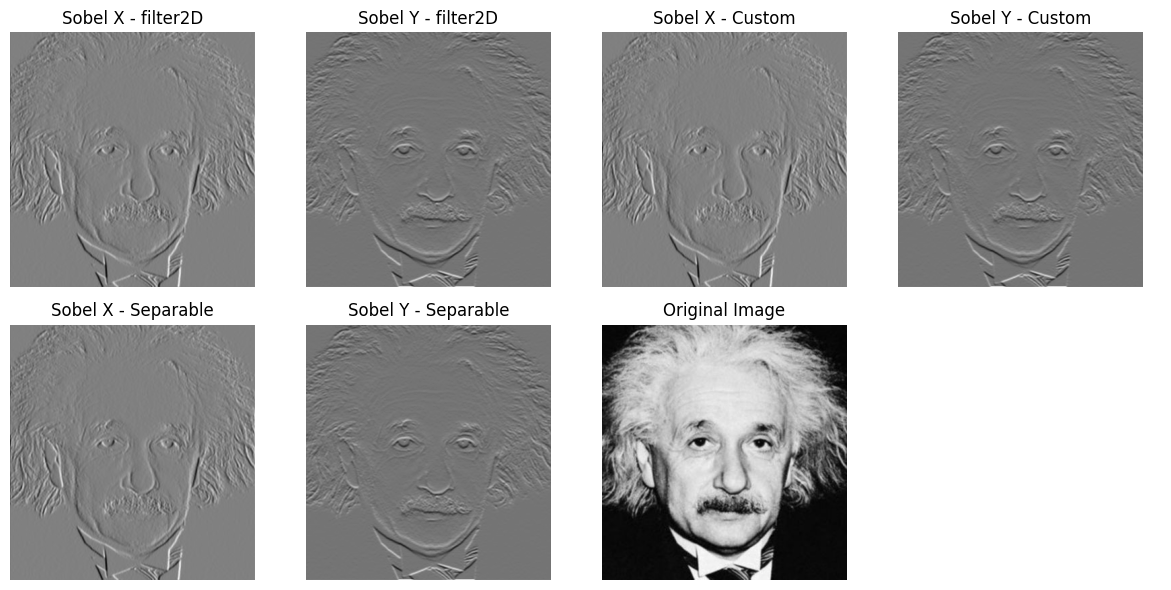

In [54]:
img = cv.imread("images/albert.png", cv.IMREAD_GRAYSCALE)

# Standard Sobel kernels
sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

# a. Using the built-in filter2D function
img_x = cv.filter2D(img, cv.CV_64F, sobel_x, borderType=cv.BORDER_CONSTANT)
img_y = cv.filter2D(img, cv.CV_64F, sobel_y,borderType=cv.BORDER_CONSTANT)

# b. Write own code to perform Sobel filtering
def sobelFilter(img, kernel):
    img_height, img_width = img.shape
    kernel_height, kernel_width = kernel.shape
    output = np.zeros((img_height, img_width), dtype=np.float64)

    # Amount of padding required
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2
    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    # Apply the kernel
    for i in range(img_height):
        for j in range(img_width):
            value = 0
            for m in range(kernel_height):
                for n in range(kernel_width):
                    value += (padded_img[i + m, j + n]* kernel[m, n])
            output[i, j] = value

    return output


# Apply custom Sobel filtering
img_x_custom = sobelFilter(img, sobel_x)
img_y_custom = sobelFilter(img, sobel_y)

# c. Using the separability property of the Sobel filter
a_x = np.array([[1], [2], [1]])
b_x = np.array([1, 0, -1])

# Apply the vertical filter
img_xa = cv.filter2D(img,cv.CV_64F,a_x,borderType=cv.BORDER_CONSTANT)
# Apply the horizontal filter
img_xb = cv.filter2D(img_xa, cv.CV_64F, b_x, borderType=cv.BORDER_CONSTANT)

a_y = np.array([[1], [0], [-1]])
b_y = np.array([1, 2, 1])
img_ya = cv.filter2D(img, cv.CV_64F, a_y, borderType=cv.BORDER_CONSTANT)
img_yb = cv.filter2D(img_ya, cv.CV_64F, b_y, borderType=cv.BORDER_CONSTANT)

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs[0, 0].imshow(img_x, cmap='gray')
axs[0, 0].set_title('Sobel X - filter2D')

axs[0, 1].imshow(img_y, cmap='gray')
axs[0, 1].set_title('Sobel Y - filter2D')

axs[0, 2].imshow(img_x_custom, cmap='gray')
axs[0, 2].set_title('Sobel X - Custom')

axs[0, 3].imshow(img_y_custom, cmap='gray')
axs[0, 3].set_title('Sobel Y - Custom')

axs[1, 0].imshow(img_xb, cmap='gray')
axs[1, 0].set_title('Sobel X - Separable')

axs[1, 1].imshow(img_yb, cmap='gray')
axs[1, 1].set_title('Sobel Y - Separable')

axs[1, 2].imshow(img, cmap='gray')
axs[1, 2].set_title('Original Image')

axs[1, 3].axis('off')

for ax in axs.flat:
    ax.axis('off')


plt.tight_layout()
plt.show()

The Sobel x filter detected vertical edges by measuring intensity changes in the horizontal direction. The Sobel y filter detected horizontal edges by measuring intensity changes in the vertical direction. The results from the three methods were similar.


##### 8. Zooming functions

A custom zoom function was implemented to scale up the small images. The function supports both nearest neighbor and bilinear interpolation by mapping each pixel in the enlarged image to the corresponding position in the original image. Then, the normalized SSD was calculated between the enlarged images and their respective original images to compare the two interpolation methods.


Normalized SSD Results
-------------------------------------------------------
Image          Nearest Neighbor             Bilinear
-------------------------------------------------------
Image 1                255.2957             200.2451
Image 2                 64.6294              48.9607
Image 3                129.7141              98.0623
Image 4                409.8873             329.2476
-------------------------------------------------------


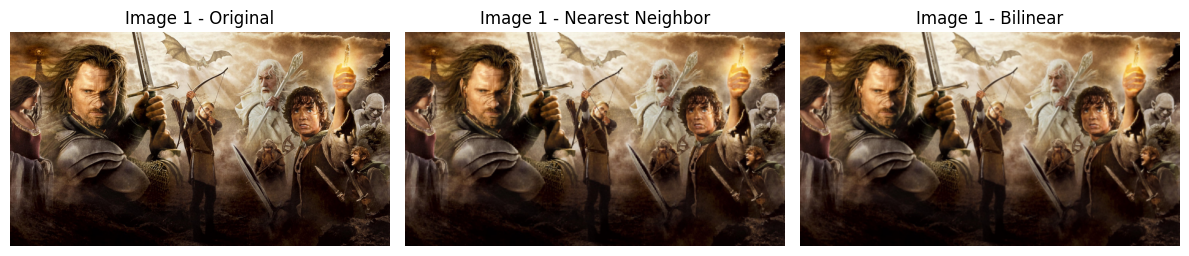

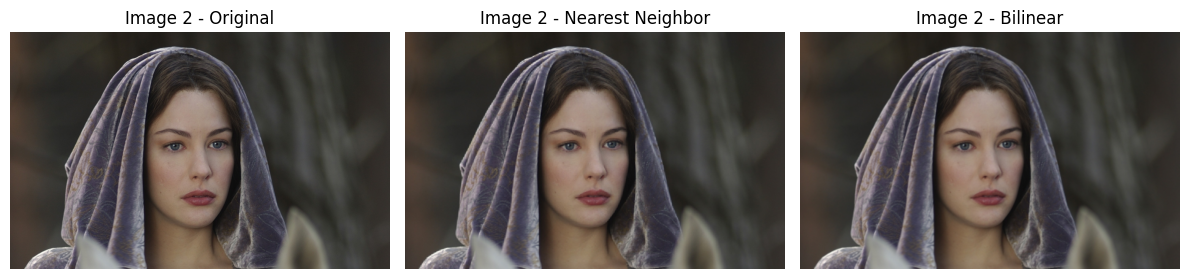

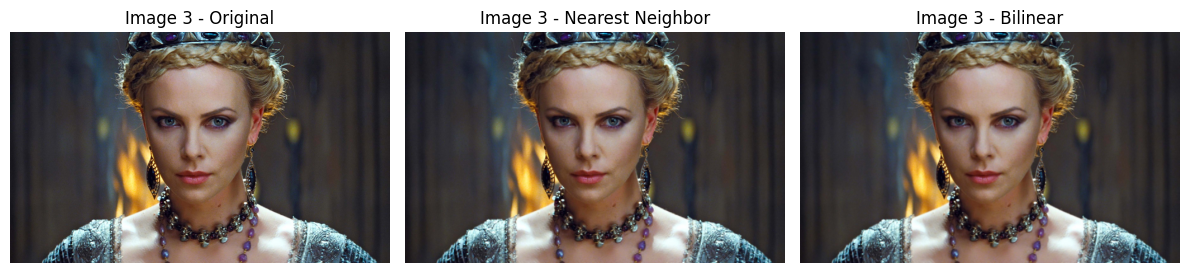

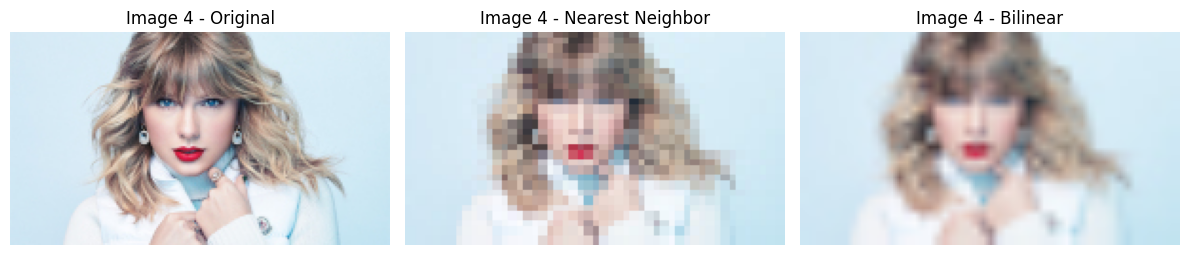

In [68]:
small_images = [cv.imread("images/im01small.png"), cv.imread("images/im02small.png"),
    cv.imread("images/im03small.png"), cv.imread("images/im04small.jpg")]
original_images = [cv.imread("images/im01.png"), cv.imread("images/im02.png"),
    cv.imread("images/im03.png"), cv.imread("images/im04.jpg")]

# Zoom an image using nearest-neighbor or bilinear interpolation
def zoom_image(image, scale, method="nearest"):
    height, width = image.shape[:2]
    new_height, new_width = int(height * scale), int(width * scale)
    output = np.zeros((new_height, new_width, image.shape[2]), dtype=np.uint8)

    for i in range(new_height):
        for j in range(new_width):
            # Map output pixel to input coordinates
            x = i / scale
            y = j / scale
            if method == "nearest": # Nearest-neighbor interpolation
                x1 = min(round(x), height - 1)
                y1 = min(round(y), width - 1)
                output[i, j] = image[x1, y1]
            elif method == "bilinear": 
                # Four neighboring pixels 
                x1, y1 = int(x), int(y)
                x2, y2 = min(x1 + 1, height - 1), min(y1 + 1, width - 1)
                dx, dy = x - x1, y - y1
                # Bilinear interpolation
                output[i, j] = ((1-dx)*(1-dy)*image[x1, y1] +
                    dx*(1-dy)*image[x2, y1] + (1-dx)*dy*image[x1, y2] +
                    dx*dy*image[x2, y2]).astype(np.uint8)
    return output

# Normalized Sum of Squared Differences
def normalized_ssd(image1, image2):
    h = min(image1.shape[0], image2.shape[0])
    w = min(image1.shape[1], image2.shape[1])
    image1 = image1[:h, :w].astype(np.float64)
    image2 = image2[:h, :w].astype(np.float64)
    difference = image1 - image2

    return np.sum(difference ** 2) / image1.size

# Zoom the four images by a factor of 4
nearest_images = [zoom_image(img, 4, "nearest") for img in small_images]
bilinear_images = [zoom_image(img, 4, "bilinear") for img in small_images]

# Calculate normalized SSD against the original images
nearest_ssd = [normalized_ssd(nearest_images[i], original_images[i]) 
               for i in range(4)]
bilinear_ssd = [ normalized_ssd(bilinear_images[i], original_images[i]) 
                for i in range(4)]

print("\nNormalized SSD Results")
print("-" * 55)
print(f"{'Image':<10} {'Nearest Neighbor':>20} {'Bilinear':>20}")
print("-" * 55)

for i in range(4):
    print(f"Image {i+1:<4} {nearest_ssd[i]:>20.4f} {bilinear_ssd[i]:>20.4f}")

print("-" * 55)


for i in range(4):
    fig, axes = plt.subplots(1, 3, figsize=(12, 16))

    # Original image
    axes[0].imshow(cv.cvtColor(original_images[i], cv.COLOR_BGR2RGB))
    axes[0].set_title(f"Image {i+1} - Original")

    # Nearest-neighbor
    axes[1].imshow(cv.cvtColor(nearest_images[i], cv.COLOR_BGR2RGB))
    axes[1].set_title(f"Image {i+1} - Nearest Neighbor")

    # Bilinear
    axes[2].imshow(cv.cvtColor(bilinear_images[i], cv.COLOR_BGR2RGB))
    axes[2].set_title(f"Image {i+1} - Bilinear")

    # Remove axes
    for j in range(3):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

The bilinear interpolation has produced smoother and more visually pleasing images, while nearest neighbor interpolation resulted in more noticeable blockiness.

##### 9.  Blurred background

The image was segmented using the GrabCut by defining a rectangular region containing the flower as the initial foreground. Then the foreground and background were separated using the resulting mask. A Gaussian blur with a 51x51 kernel was then applied to the image and the segmentation mask was used to retain the original flower while replacing the background with the blurred image.

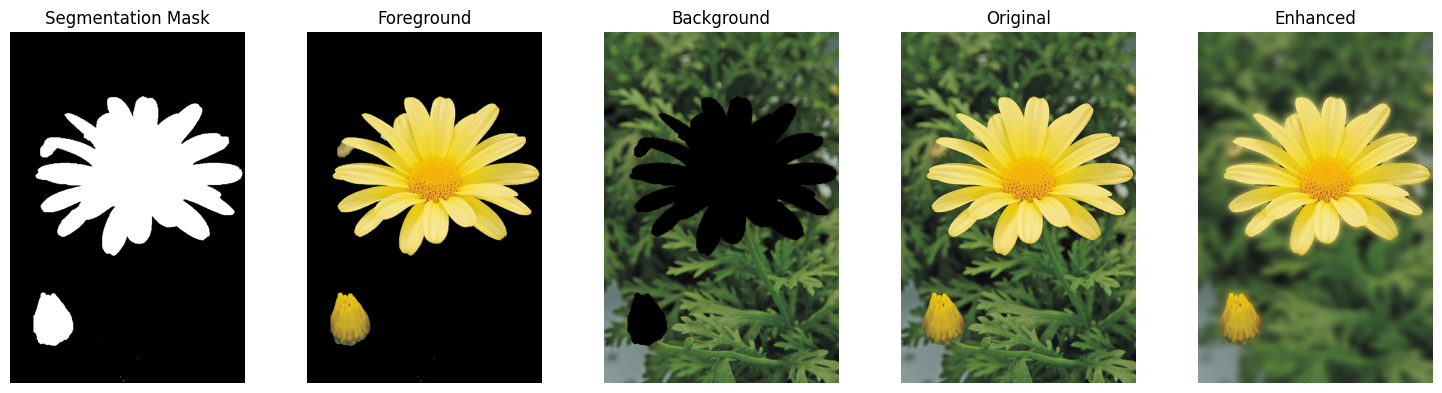

In [56]:
img = cv.imread("images/flower.jpeg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
height, width = img.shape[:2]

# Initialize GrabCut
mask = np.zeros((height, width), np.uint8)
bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)

# Rough region containing the flower
region = (int(0.1 * width), int(0.1 * height),int(0.9 * width), int(0.9 * height))
cv.grabCut(img, mask, region, bg_model, fg_model,5, cv.GC_INIT_WITH_RECT)

# Binary foreground mask
fg_mask = np.where(
    (mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 1, 0).astype(np.uint8)

mask_3ch = fg_mask[:, :, np.newaxis]
# Foreground and background
foreground = img_rgb * mask_3ch
background = img_rgb * (1 - mask_3ch)
# Blur original image, then replace only the background
blurred_img = cv.GaussianBlur(img_rgb, (51, 51), 0)
enhanced_img = img_rgb * mask_3ch + blurred_img * (1 - mask_3ch)

# Display
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
axes[0].imshow(fg_mask, cmap="gray")
axes[0].set_title("Segmentation Mask")

axes[1].imshow(foreground)
axes[1].set_title("Foreground")

axes[2].imshow(background)
axes[2].set_title("Background")

axes[3].imshow(img_rgb)
axes[3].set_title("Original")

axes[4].imshow(enhanced_img)
axes[4].set_title("Enhanced")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

The GrabCut algorithm successfully separated the flower from the background. The enhanced image kept the flower sharp and blurred the background.

##### Why is the background just beyond the edge of the flower quite dark in the enhanced image?

The background image contains zero valued (black color) pixels in the foreground region. Therefore when the background is blurred using a Gaussian kernel, pixels near the flower boundary are averaged with these black pixels. As a result, the background just beyond the edge of the flower becomes darker.

##### 10. Smoothen the image while keeping the edges sharp

The image was smoothed using OpenCV bilateral filter with a 9×9 neighborhood, a spatial sigma of 3, and a color sigma of 50. A Gaussian blur with a similar 9×9 kernel was also applied for comparison. Then, a custom bilateral filter was implemented by calculating spatial and intensity weights for neighboring pixels and combining them to smooth the image.

MSE between OpenCV and custom bilateral filter: 15.2455432440751
MSE between OpenCV and Gaussian filter: 380.38630347799324


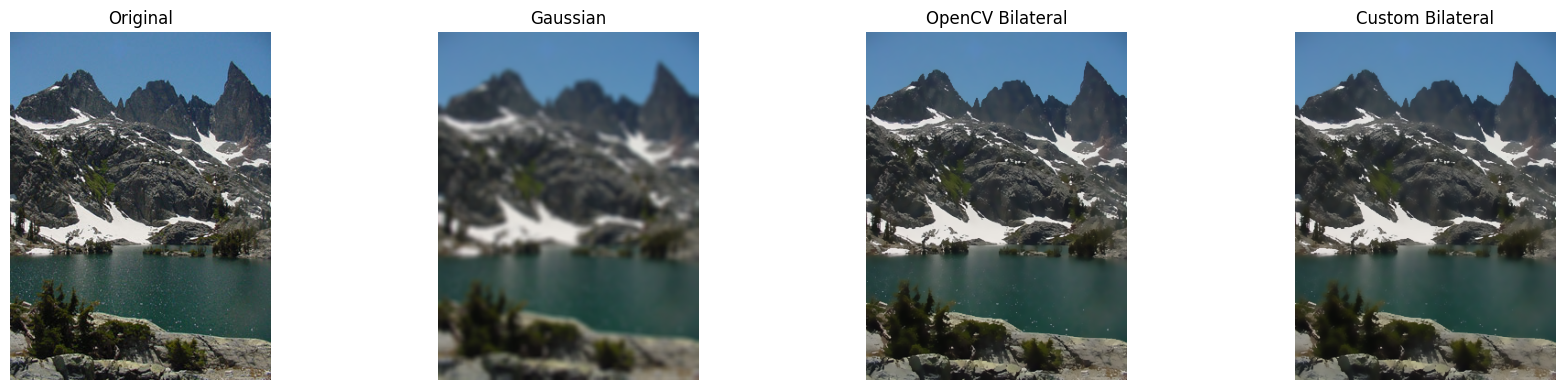

In [61]:
img = cv.imread("images/lake.jpeg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Filter parameters
d = 9
sigma_space = 3
sigma_color = 50

# OpenCV bilateral and Gaussian filters
bilateral_cv = cv.bilateralFilter(img_rgb, d, sigma_color, sigma_space)
gaussian = cv.GaussianBlur(img_rgb, (d, d), sigmaX=sigma_space)

# Custom bilateral filter
def bilateral_filter(img, d, sigma_space, sigma_color):
    img = img.astype(np.float64)
    h, w, c = img.shape
    r = d // 2
    padded_img = cv.copyMakeBorder(img, r, r, r, r, cv.BORDER_REFLECT)
    # Spatial Gaussian weights
    coords = np.arange(-r, r + 1)
    xx, yy = np.meshgrid(coords, coords)
    spatial = np.exp(-(xx**2 + yy**2) / (2 * sigma_space**2))
    output = np.zeros_like(img)
    weight_sum = np.zeros((h, w, 1))

    for i in range(d):
        for j in range(d):
            neighbor = padded_img[i:i+h, j:j+w]
            px_difference = neighbor - img       
            # Range/intensity weights
            distance = np.sum(px_difference**2, axis=2, keepdims=True)
            range_weight = np.exp(-distance / (2 * sigma_color**2))
            weight = spatial[i, j] * range_weight
            output += weight * neighbor
            weight_sum += weight
    return output / (weight_sum + 1e-8)


custom_bilateral = bilateral_filter(
    img_rgb, d, sigma_space, sigma_color).astype(np.uint8)

# Comparison using MSE
mse1 = np.mean((bilateral_cv.astype(np.float64) -
     custom_bilateral.astype(np.float64)) ** 2)
mse2 = np.mean((bilateral_cv.astype(np.float64) -
     gaussian.astype(np.float64)) ** 2)

print("MSE between OpenCV and custom bilateral filter:", mse1)
print("MSE between OpenCV and Gaussian filter:", mse2)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")

axes[1].imshow(gaussian)
axes[1].set_title(f"Gaussian")

axes[2].imshow(bilateral_cv)
axes[2].set_title("OpenCV Bilateral")

axes[3].imshow(custom_bilateral)
axes[3].set_title("Custom Bilateral")

for ax in axes:
    ax.axis("off")

plt.tight_layout(); plt.show()

The Gaussian filter smoothed the image but also blurred the edges, while the bilateral filters provided smoothing while better preserving the edges. The MSE between the Gaussian filter and the OpnenCV bilateral filter was 380.3863 indicating a large difference between the two results. 

The custom bilateral filter produced a result approximately similar to OpenCV implementation. The MSE between the OpenCV and custom bilateral filtered images was 15.2455, indicating a relatively small difference between the two results.